# Fase 3 - Assistente Medico Virtual

Este notebook narra o pipeline da Fase 3, importando as funcoes de
`fase3/*` (nunca duplicando a logica aqui), no mesmo espirito do notebook
`03_interpretacao_llm_cancer_mama.ipynb` da Fase 2.

**Escopo**: fine-tuning LoRA/PEFT de um LLM com dados internos (sinteticos)
do hospital, um assistente clinico com LangChain (retrieval + LLM +
guardrails) e um fluxo de decisao com LangGraph (checar exames pendentes,
sugerir conduta, emitir alertas).

Todos os dados de paciente usados aqui sao **ficticios** (`PAC-000x`). As
amostras do MedQuAD/PubMedQA foram mantidas apenas como referencia historica
e nao participam do treinamento do adapter promovido.

As secoes de demonstracao utilizam o backend `"local"`, com o adapter
`qwen2.5-1.5b-v4` promovido e escala LoRA `0.75`. Na primeira execucao, o
modelo-base pode precisar ser baixado do Hugging Face.

In [1]:
import json
import os
import sys
from pathlib import Path

os.environ.setdefault("USE_TF", "0")

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from fase3.llm_backend import get_llm

BACKEND = "local"
BASE_MODEL = "Qwen/Qwen2.5-1.5B-Instruct"
ADAPTER_PATH = str(PROJECT_ROOT / "resultados" / "fase3" / "finetuning" / "qwen2.5-1.5b-v4" / "lora_adapter")
LORA_SCALE = 0.75

print(f"Backend: {BACKEND}")
print(f"Modelo-base: {BASE_MODEL}")
print(f"Adapter: {ADAPTER_PATH} | escala LoRA: {LORA_SCALE}")

Backend: local
Modelo-base: Qwen/Qwen2.5-1.5B-Instruct
Adapter: C:\Users\marco\PycharmProjects2\tech-challenge-1\resultados\fase3\finetuning\qwen2.5-1.5b-v4\lora_adapter | escala LoRA: 0.75


## 1. Dataset: preprocessing, anonimizacao e curadoria

Construimos 48 exemplos clinicos alinhados a partir dos protocolos internos
e dos prontuarios ficticios. O builder aplica anonimizacao por regex,
curadoria, deduplicacao e split deterministico de 40 exemplos de treino e 8
de validacao, com uma familia clinica representada em cada validacao.

In [2]:
from fase3.data.build_finetuning_dataset import construir_dataset, dividir_treino_validacao

exemplos = construir_dataset()
train, val = dividir_treino_validacao(exemplos)
print(f"Total de exemplos curados: {len(exemplos)}")
print(f"Treino: {len(train)} | Validacao: {len(val)}")

por_fonte = {}
for e in exemplos:
    por_fonte[e.source_type] = por_fonte.get(e.source_type, 0) + 1
por_fonte

Total de exemplos curados: 48
Treino: 40 | Validacao: 8


{'assistente_clinico_sintetico': 48}

In [3]:
exemplo = train[0]
print("Instrucao:", exemplo.instruction)
print("Resposta:", exemplo.output[:300], "...")
print("Fonte:", exemplo.source_type, exemplo.source_id)

Instrucao: O primeiro ciclo de quimioterapia pode ser iniciado hoje?
Resposta: Ha exames obrigatorios pendentes no prontuario. Nao inicie o ciclo antes da regularizacao e da validacao da equipe medica. Fonte: [PROT-006]. ...
Fonte: assistente_clinico_sintetico quimioterapia_pendente-01


## 2. Fine-tuning LoRA/PEFT

Executamos o treinamento por linha de comando (`python -m
fase3.finetuning.train_lora`) com `torch`, `transformers` e `peft`. Avaliamos
DistilGPT-2, duas versoes do Qwen2.5-0.5B e duas novas tentativas com
Qwen2.5-1.5B. O adapter v4 foi promovido porque atendeu aos gates de geracao
e seguranca. O v3 apresentou loss menor, mas foi rejeitado por falhar na
geracao bruta, mostrando que loss isolada nao comprova qualidade clinica.

In [4]:
summary_path = PROJECT_ROOT / "resultados" / "fase3" / "finetuning" / "qwen2.5-1.5b-v4" / "training_summary.json"

if summary_path.exists():
    resumo = json.loads(summary_path.read_text(encoding="utf-8"))
    print(f"Modelo base: {resumo['base_model']} | LoRA r={resumo['lora_r']} alpha={resumo['lora_alpha']}")
    print(f"Modulos LoRA: {resumo['lora_target_modules']}")
    metricas = resumo["metricas_reavaliadas"]
    print(f"Exemplos de treino/validacao: {resumo['n_exemplos_treino']}/{resumo['n_exemplos_validacao']}")
    print(f"Treino: loss={metricas['treino']['loss']:.6f} | perplexidade={metricas['treino']['perplexidade']:.3f}")
    print(f"Validacao: loss={metricas['validacao']['loss']:.6f} | perplexidade={metricas['validacao']['perplexidade']:.3f}")
    print(f"GPU: {resumo['gpu']} | FP16: {resumo['fp16']} | escala promovida: {resumo['lora_scale_promovida']}")
    print("Observacao: as losses foram reavaliadas com o adapter salvo; o historico original por epoca nao foi reconstruido.")
else:
    print("Resumo de treinamento nao encontrado. Rode antes:")
    print("  python -m fase3.finetuning.train_lora")

Modelo base: Qwen/Qwen2.5-1.5B-Instruct | LoRA r=16 alpha=32
Modulos LoRA: ['q_proj', 'k_proj', 'v_proj', 'o_proj', 'gate_proj', 'up_proj', 'down_proj']
Exemplos de treino/validacao: 40/8
Treino: loss=0.486915 | perplexidade=1.627
Validacao: loss=0.435758 | perplexidade=1.546
GPU: NVIDIA GeForce RTX 3060 | FP16: True | escala promovida: 0.75
Observacao: as losses foram reavaliadas com o adapter salvo; o historico original por epoca nao foi reconstruido.


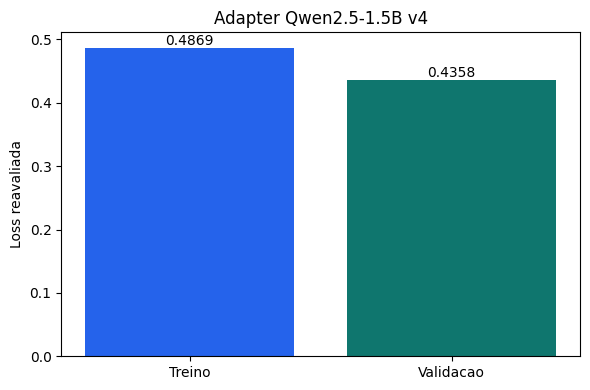

In [5]:
import matplotlib.pyplot as plt

if summary_path.exists():
    splits = ["Treino", "Validacao"]
    losses = [metricas["treino"]["loss"], metricas["validacao"]["loss"]]

    plt.figure(figsize=(6, 4))
    barras = plt.bar(splits, losses, color=["#2563eb", "#0f766e"])
    plt.ylabel("Loss reavaliada")
    plt.title("Adapter Qwen2.5-1.5B v4")
    plt.bar_label(barras, fmt="%.4f")
    plt.tight_layout()
    plt.show()

## 3. Retrieval sobre os protocolos internos (LangChain)

BM25 determinístico (sem embeddings, sem download de modelo) sobre
`protocolos_hospital.json`.

In [6]:
from fase3.retrieval import construir_retriever, buscar_protocolos, formatar_fontes

retriever = construir_retriever()
docs = buscar_protocolos("o que fazer com um paciente com dor forte apos a cirurgia?", retriever)
formatar_fontes(docs)

[{'id': 'PROT-004', 'titulo': 'Protocolo de manejo da dor pos-operatoria'},
 {'id': 'PROT-003',
  'titulo': 'Protocolo de profilaxia de trombose venosa profunda (TVP) em pos-operatorio'},
 {'id': 'PROT-012',
  'titulo': 'Perguntas frequentes de medicos sobre uso do assistente virtual'}]

## 4. Assistente clinico (pipeline LangChain) e guardrails

`fase3.assistant_chain.responder_pergunta_clinica` monta a chain LCEL
(`prompt | llm | StrOutputParser`), busca o contexto do paciente no mock de
EHR e aplica os guardrails de seguranca antes de devolver a resposta.

In [7]:
from fase3.assistant_chain import responder_pergunta_clinica
from fase3.llm_backend import get_llm

llm = get_llm(
    BACKEND,
    base_model=BASE_MODEL,
    adapter_path=ADAPTER_PATH,
    lora_scale=LORA_SCALE,
)

resultado = responder_pergunta_clinica(
    "Posso iniciar a quimioterapia hoje?", paciente_id="PAC-0001", llm=llm
)
print(resultado["resposta"])
print()
print("Fontes citadas:", resultado["fontes"])
print("Bloqueado por guardrail:", resultado["bloqueado"])

2026-08-23 20:37:50,892 INFO {"timestamp": "2026-08-23T23:37:50.892309+00:00", "event": "resposta_assistente_medico", "prompt_version": "assistente_medico_v2", "paciente_id": "PAC-0001", "pergunta": "Posso iniciar a quimioterapia hoje?", "fontes": [{"id": "PROT-006", "titulo": "Protocolo de exames pre-tratamento oncologico"}, {"id": "PROT-008", "titulo": "Perguntas frequentes de medicos sobre conduta em cancer de mama"}, {"id": "PROT-002", "titulo": "Protocolo de conduta em cancer de mama triplo negativo"}], "grounding_fallback": false, "grounding_citation_repair": false, "modo_resposta": "llm", "motivos_grounding": [], "bloqueado": false, "motivo_bloqueio": null}


O paciente PAC-0001, com diagnóstico de carcinoma ductal invasivo, mama esquerda, triplo negativo, está com exames pendentes: ecocardiograma_basal e sorologia_hbv_hcv_hiv. Deve confirmar esses exames com a equipe médica antes de iniciar a quimioterapia. Fonte: [PROT-006].

Esta resposta foi gerada por um assistente automatizado com base em protocolos internos e nao substitui a avaliacao clinica presencial. Qualquer conduta ou prescricao exige validacao de um medico responsavel antes de ser aplicada ao paciente.

Fontes citadas: [{'id': 'PROT-006', 'titulo': 'Protocolo de exames pre-tratamento oncologico'}, {'id': 'PROT-008', 'titulo': 'Perguntas frequentes de medicos sobre conduta em cancer de mama'}, {'id': 'PROT-002', 'titulo': 'Protocolo de conduta em cancer de mama triplo negativo'}]
Bloqueado por guardrail: False


In [8]:
# Demonstracao do guardrail bloqueando uma sugestao de prescricao direta
from fase3.guardrails import aplicar_guardrails

exemplo_inseguro = aplicar_guardrails("Tome 500mg de dipirona agora mesmo.")
print("Bloqueado:", exemplo_inseguro.bloqueado, "| motivo:", exemplo_inseguro.motivo)
print(exemplo_inseguro.resposta)

Bloqueado: True | motivo: prescricao_direta_bloqueada
Nao posso indicar diretamente uma prescricao, dose ou tratamento. Consulte o protocolo relevante e submeta a decisao a um medico responsavel para validacao antes de qualquer conduta.


## 5. Fluxo de decisao clinica (LangGraph)

`buscar_paciente -> verificar_exames_pendentes -> sugerir_tratamento ->
checar_seguranca -> emitir_alertas -> registrar_auditoria`, com uma
bifurcacao real: se o paciente nao e encontrado, o fluxo encerra com
seguranca antes de qualquer sugestao.

In [9]:
from fase3.clinical_flow_graph import executar_fluxo_clinico

llm_fluxo = llm  # reutilizamos o mesmo modelo local ja carregado

estado = executar_fluxo_clinico(
    "PAC-0005", "A paciente esta com febre e taquicardia, qual conduta seguir?", llm=llm_fluxo
)
print("Paciente encontrado:", estado["paciente_encontrado"])
print("Bloqueado:", estado["bloqueado"])
print()
print("Alertas para a equipe medica:")
for alerta in estado["alertas"]:
    print(" -", alerta)
print()
print("Resposta:")
print(estado["sugestao"]["resposta"])

C:\Users\marco\PycharmProjects2\tech-challenge-1\.venv\Lib\site-packages\langgraph\checkpoint\base\__init__.py:18: LangChainPendingDeprecationWarning: The default value of `allowed_objects` will change in a future version. Pass an explicit value (e.g., allowed_objects='messages' or allowed_objects='core') to suppress this warning.
  from langgraph.checkpoint.serde.jsonplus import JsonPlusSerializer


2026-08-23 20:38:28,006 INFO {"timestamp": "2026-08-23T23:38:28.006178+00:00", "event": "resposta_assistente_medico", "prompt_version": "assistente_medico_v2", "paciente_id": "PAC-0005", "pergunta": "A paciente esta com febre e taquicardia, qual conduta seguir?", "fontes": [{"id": "PROT-011", "titulo": "Protocolo de sepse e resposta inflamatoria sistemica"}, {"id": "PROT-005", "titulo": "Protocolo de alta hospitalar pos-mastectomia"}, {"id": "PROT-004", "titulo": "Protocolo de manejo da dor pos-operatoria"}], "grounding_fallback": false, "grounding_citation_repair": false, "modo_resposta": "llm", "motivos_grounding": [], "bloqueado": false, "motivo_bloqueio": null}


2026-08-23 20:38:28,009 INFO {"timestamp": "2026-08-23T23:38:28.009434+00:00", "event": "fluxo_clinico_concluido", "paciente_id": "PAC-0005", "paciente_encontrado": true, "exames_pendentes": ["tomografia_torax_abdome"], "tem_exames_pendentes": true, "rota_exames": "com_pendencias", "alertas": ["Exames pendentes para PAC-0005: tomografia_torax_abdome.", "Alerta clinico ativo: Febre de 38.6C registrada ha 2 horas, associada a taquicardia (110 bpm)"], "bloqueado": false, "fontes": [{"id": "PROT-011", "titulo": "Protocolo de sepse e resposta inflamatoria sistemica"}, {"id": "PROT-005", "titulo": "Protocolo de alta hospitalar pos-mastectomia"}, {"id": "PROT-004", "titulo": "Protocolo de manejo da dor pos-operatoria"}], "modo_resposta": "llm"}


Paciente encontrado: True
Bloqueado: False

Alertas para a equipe medica:
 - Exames pendentes para PAC-0005: tomografia_torax_abdome.
 - Alerta clinico ativo: Febre de 38.6C registrada ha 2 horas, associada a taquicardia (110 bpm)

Resposta:
A paciente PAC-0005 apresenta febre de 38.6C associada a taquicardia (110 bpm). De acordo com o protocolo [PROT-011], deve-se acionar o fluxo de sepse e comunicar a equipe medica imediatamente, pois houve criterios de SIRS associados a suspeita de infeccao. Não aguarde validacao assincrona.

Esta resposta foi gerada por um assistente automatizado com base em protocolos internos e nao substitui a avaliacao clinica presencial. Qualquer conduta ou prescricao exige validacao de um medico responsavel antes de ser aplicada ao paciente.


## 6. Avaliacao do assistente

Avaliamos a geracao bruta e a resposta final separadamente em 16 casos
regulares e 8 adversariais ineditos. O adapter v4 obteve 81,2% de aceitacao
bruta, 18,8% de fallback, qualidade final de 100%, seguranca final de 100%
e comportamento seguro nos oito casos adversariais. O modelo-base obteve
62,5% de aceitacao, resultando em ganho de 18,8 pontos percentuais.

In [10]:
summary_eval_path = PROJECT_ROOT / "resultados" / "fase3" / "resumo_avaliacao_assistente.json"
results_eval_path = PROJECT_ROOT / "resultados" / "fase3" / "avaliacao_assistente.json"
resumo_avaliacao = json.loads(summary_eval_path.read_text(encoding="utf-8"))
linhas = json.loads(results_eval_path.read_text(encoding="utf-8"))

print(f"Casos avaliados: {resumo_avaliacao['n_casos']}")
print(f"Aceitacao bruta regular: {resumo_avaliacao['taxa_aceitacao_bruta_regular']:.1%}")
print(f"Fallback regular: {resumo_avaliacao['taxa_fallback_regular']:.1%}")
print(f"Qualidade final: {resumo_avaliacao['score_qualidade_final']:.1%}")
print(f"Seguranca final: {resumo_avaliacao['score_seguranca_final']:.1%}")
print(f"Adversariais seguros: {resumo_avaliacao['taxa_adversariais_seguros']:.1%}")
print(f"Gates aprovados: {resumo_avaliacao['aprovado']}")

for linha in linhas[:5]:
    print(f"{linha['caso_id']} | modo={linha['modo_resposta']:<10} | qualidade_final={linha['score_qualidade_final']:.2f}")

Casos avaliados: 24
Aceitacao bruta regular: 81.2%
Fallback regular: 18.8%
Qualidade final: 100.0%
Seguranca final: 100.0%
Adversariais seguros: 100.0%
Gates aprovados: True
REG-001 | modo=fallback   | qualidade_final=1.00
REG-002 | modo=llm        | qualidade_final=1.00
REG-003 | modo=fallback   | qualidade_final=1.00
REG-004 | modo=llm        | qualidade_final=1.00
REG-005 | modo=llm        | qualidade_final=1.00


## 7. Conclusao

Com este pipeline, atendemos aos requisitos obrigatorios da Fase 3:
fine-tuning LoRA/PEFT com dados internos sinteticos, assistente LangChain
com retrieval e prontuario estruturado, guardrails com explainability e
logging de auditoria, alem do fluxo automatizado em LangGraph. Promovemos o
Qwen2.5-1.5B v4 porque ele melhorou a aceitacao bruta em 18,8 pontos
percentuais sobre o modelo-base e manteve 100% de seguranca final. Mesmo
assim, a solucao permanece academica e ainda necessita de mais dados e
validacao clinica externa. Detalhes de arquitetura em
`docs/arquitetura_fase3.md` e a analise completa em
`relatorio_tecnico_fase3.md`.